In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importation des bibliothèques nécessaires

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, f1_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler

## Définition du chemin d'accès aux données

In [ ]:
folder_path = "/content/drive/MyDrive/Predicting-the-results-of-a-match"

## Chargement du jeu de données

In [ ]:
df = pd.read_csv(folder_path+"/Data/dataset_match_classification.csv")
print(f"Successfully loaded data")

Successfully loaded data


## Affichage des dimensions initiales du DataFrame

In [ ]:
df.shape

(12680, 20)

### Vérification initiale des valeurs manquantes

In [ ]:
df.isnull().sum()

,0
season,0
leagueID,0
home_goals,0
home_xGoals,0
home_shots,0
home_shotsOnTarget,0
home_corners,0
home_ppda,0
home_yellowCards,1
home_redCards,0


### Suppression des lignes avec des valeurs manquantes

In [ ]:
df.dropna(inplace=True)

### Re-vérification des valeurs manquantes après nettoyage

In [ ]:
df.isnull().sum()

,0
season,0
leagueID,0
home_goals,0
home_xGoals,0
home_shots,0
home_shotsOnTarget,0
home_corners,0
home_ppda,0
home_yellowCards,0
home_redCards,0


### Analyse de la distribution de 'leagueID'

In [ ]:
df["leagueID"].value_counts()

,count
leagueID,
1,2660
4,2660
2,2659
5,2558
3,2142


### Analyse de la distribution de 'season'

In [ ]:
df["season"].value_counts()

,count
season,
2015,1826
2018,1826
2017,1826
2020,1826
2016,1825
2014,1825
2019,1725


### Suppression des colonnes 'leagueID' et 'season'

In [ ]:
df.drop(columns=['leagueID','season'], inplace=True)

### Vérification des doublons exacts

In [ ]:
df.duplicated().sum()

np.int64(0)

### Vérification des doublons sur un sous-ensemble de colonnes

In [ ]:
df.duplicated(subset=['home_goals','away_goals','home_corners','away_corners','home_ppda','away_ppda','target']).sum()

np.int64(0)

### Affichage des types de données actuels

In [ ]:
df.dtypes

,0
home_goals,int64
home_xGoals,float64
home_shots,int64
home_shotsOnTarget,int64
home_corners,int64
home_ppda,float64
home_yellowCards,float64
home_redCards,int64
away_goals,int64
away_xGoals,float64


### Conversion des types de données pour les cartes et les xGoals

In [ ]:
df['home_yellowCards'] = df['home_yellowCards'].astype('int')
df['home_redCards'] = df['home_redCards'].astype('int')
df['away_yellowCards'] = df['away_yellowCards'].astype('int')
df['away_redCards'] = df['away_redCards'].astype('int')
df['home_xGoals'] = df['home_xGoals'].astype('int')
df['away_xGoals'] = df['away_xGoals'].astype('int')

### Conversion de la colonne 'target' en type catégoriel

In [ ]:
df['target'] = df['target'].astype('category')

### Conversion de la colonne 'target_code' en entier

In [ ]:
df['target_code'] = df['target_code'].astype('int')

### Affichage des statistiques descriptives du DataFrame

In [ ]:
df.describe()

,home_goals,home_xGoals,home_shots,home_shotsOnTarget,home_corners,home_ppda,home_yellowCards,home_redCards,away_goals,away_xGoals,away_shots,away_shotsOnTarget,away_corners,away_ppda,away_yellowCards,away_redCards,target_code
count,12679.000000,12679.000000,12679.000000,12679.000000,12679.000000,12679.000000,12679.000000,12679.000000,12679.000000,12679.000000,12679.000000,12679.000000,12679.000000,12679.000000,12679.000000,12679.000000,12679.000000
mean,1.533244,1.005521,13.707232,4.742488,5.487972,10.496088,1.922470,0.089912,1.206641,0.695007,11.216815,3.892815,4.467781,11.835493,2.141809,0.116413,0.858033
std,1.306775,0.929593,5.264522,2.578691,2.955818,5.609505,1.352601,0.303201,1.167763,0.805780,4.656940,2.281557,2.603537,6.925530,1.374073,0.340069,0.854286
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.897400,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.122000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,10.000000,3.000000,3.000000,6.814800,1.000000,0.000000,0.000000,0.000000,8.000000,2.000000,3.000000,7.483350,1.000000,0.000000,0.000000
50%,1.000000,1.000000,13.000000,4.000000,5.000000,9.250000,2.000000,0.000000,1.000000,1.000000,11.000000,4.000000,4.000000,10.228600,2.000000,0.000000,1.000000
75%,2.000000,2.000000,17.000000,6.000000,7.000000,12.614150,3.000000,0.000000,2.000000,1.000000,14.000000,5.000000,6.000000,14.191400,3.000000,0.000000,2.000000
max,10.000000,6.000000,47.000000,18.000000,20.000000,97.333300,8.000000,3.000000,9.000000,6.000000,39.000000,15.000000,19.000000,152.000000,9.000000,3.000000,2.000000


### Distribution des cartons rouges à domicile

In [ ]:
df['home_redCards'].value_counts()

,count
home_redCards,
0,11602
1,1015
2,61
3,1


### Distribution des cartons rouges à l'extérieur

In [ ]:
df['away_redCards'].value_counts()

,count
away_redCards,
0,11283
1,1317
2,78
3,1


In [ ]:
df.drop(columns=['home_goals', 'home_xGoals', 'away_goals', 'away_xGoals'], inplace=True)

### Vérification de la forme du DataFrame après prétraitement

In [ ]:
df.shape

(12679, 14)

### Visualisation des distributions des features numériques

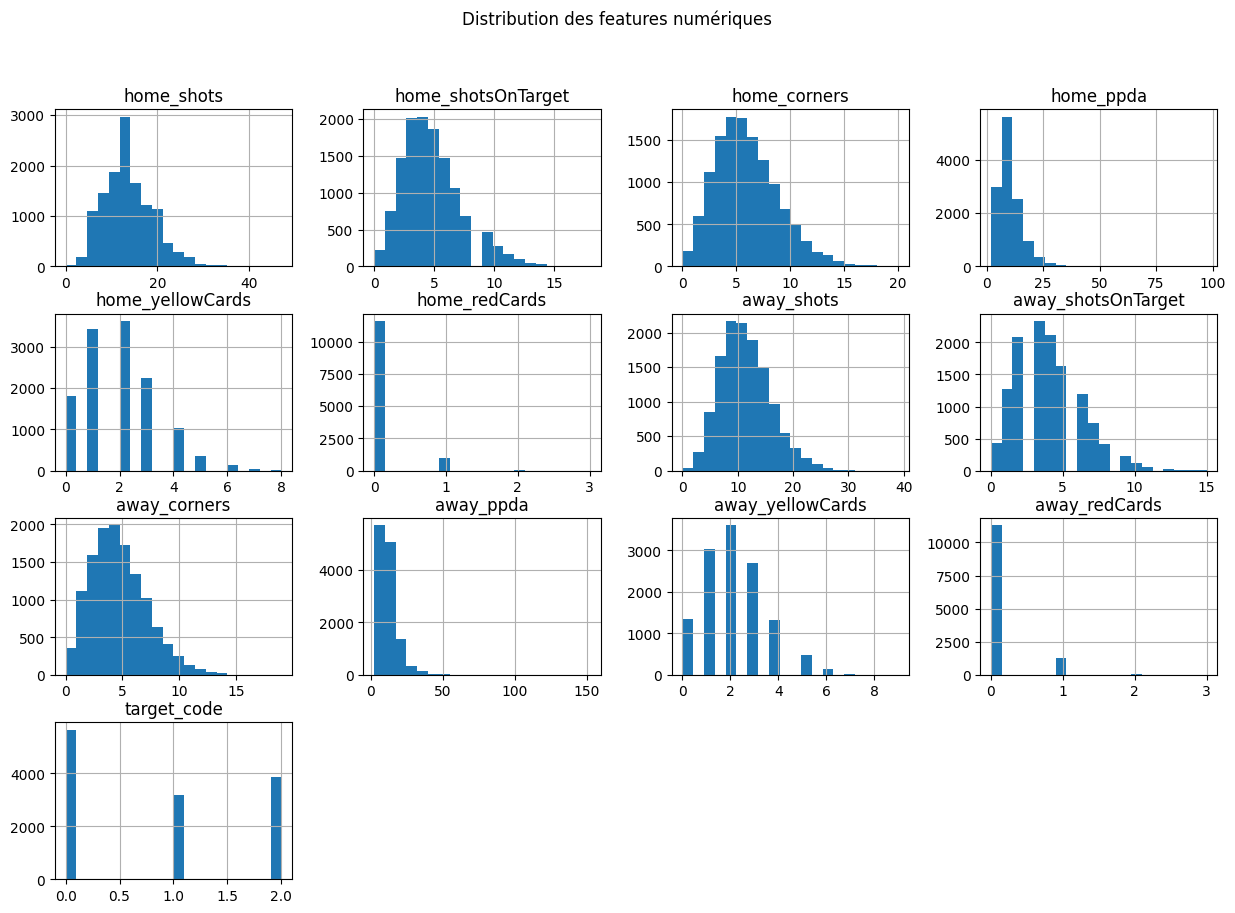

In [ ]:
num_features = (df.columns)[:16]
df[num_features].hist(figsize=(15,10), bins=20)
plt.suptitle("Distribution des features numériques")
plt.show()

### Visualisation de la distribution de la variable cible

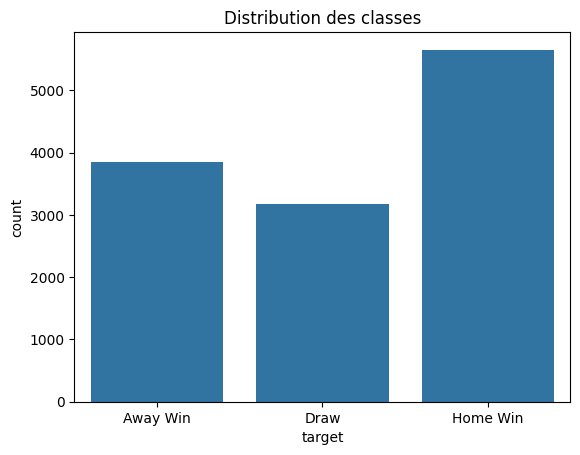

In [ ]:
sns.countplot(x='target', data=df)
plt.title("Distribution des classes")
plt.show()

### Définition de la fonction de tracé de boxplots

In [ ]:
def Boxplot_featrures(df, num_features,title="Boxplot des features numériques pour détecter les outliers"):
  plt.figure(figsize=(15,5))
  sns.boxplot(data=df[num_features])
  plt.title(title)
  plt.show()

### Boxplots pour les features de l'équipe à domicile

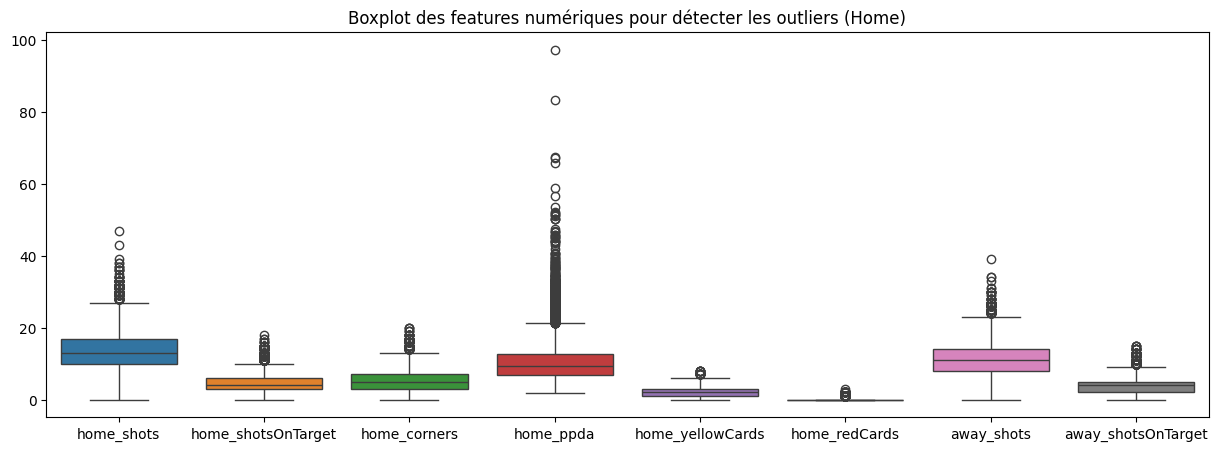

In [ ]:
Boxplot_featrures(df, num_features[:8],title="Boxplot des features numériques pour détecter les outliers (Home)")

### Boxplots pour les features de l'équipe à l'extérieur

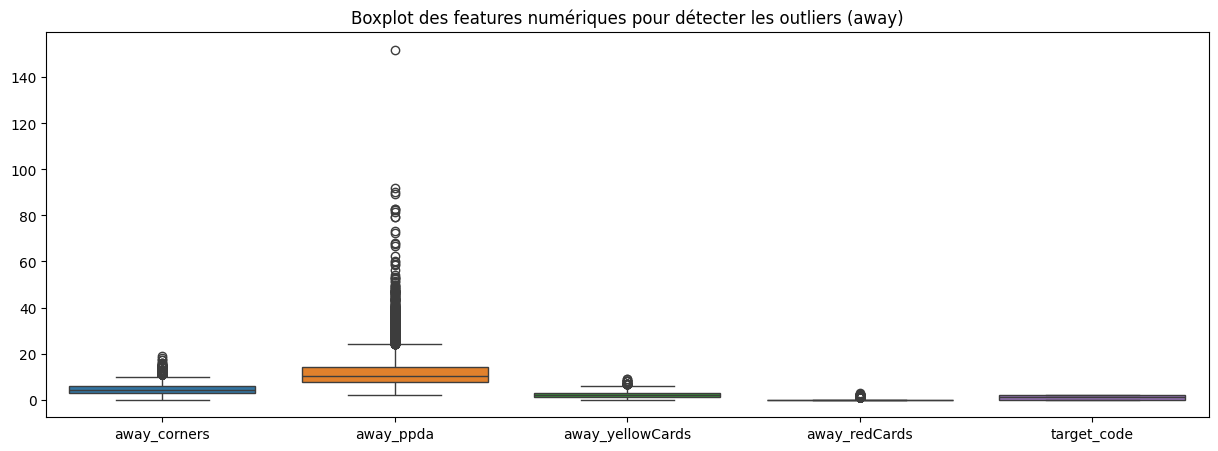

In [ ]:
Boxplot_featrures(df, num_features[8:],title="Boxplot des features numériques pour détecter les outliers (away)")

## Vérification de la distribution de la cible

In [ ]:
df['target'].value_counts()

,count
target,
Home Win,5654
Away Win,3854
Draw,3171


## Séparation des features (X) et de la cible (y)

In [ ]:
X = df.drop(columns=['target','target_code'])
y = df['target_code']

## Calcul de la matrice de corrélation avec la cible

In [ ]:
features_for_corr = [col for col in num_features if col != 'target']
corr_matrix = df[features_for_corr].corr()

## Visualisation de la matrice de corrélation

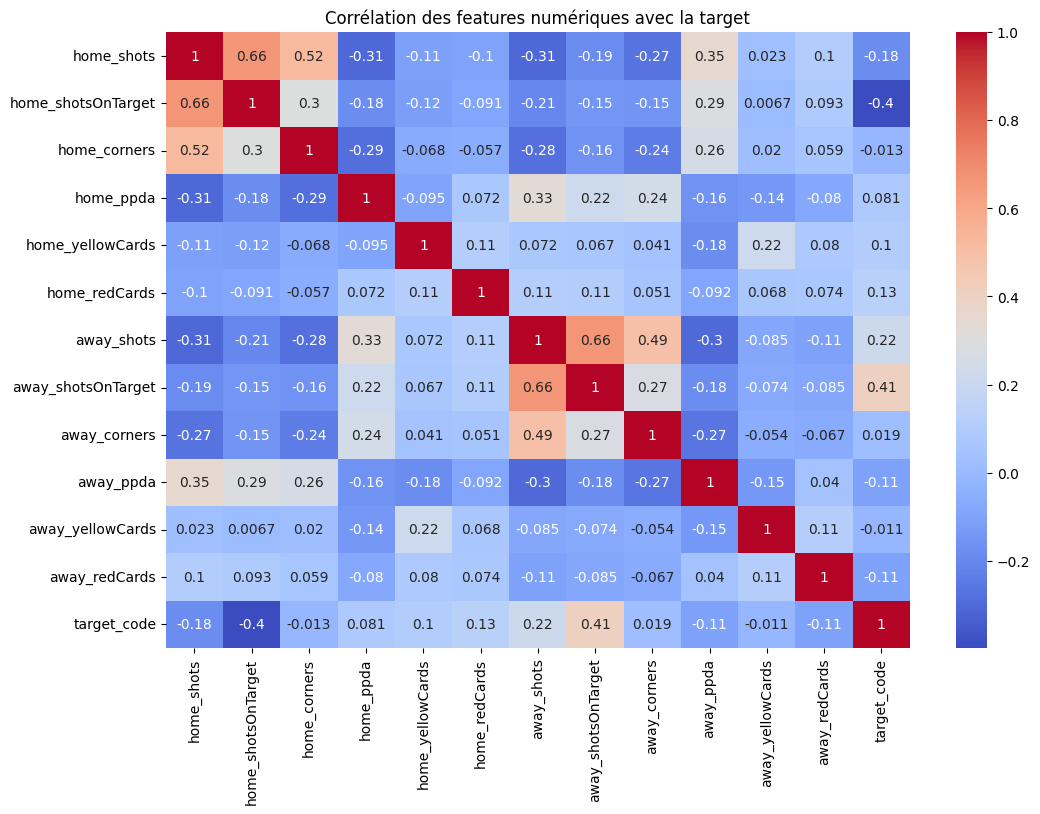

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Corrélation des features numériques avec la target")
plt.show()

## Filtrage des features avec une corrélation supérieure à 0.05

In [ ]:
# On peut sélectionner les features ayant corrélation > |0.05|
corr_target = corr_matrix['target_code'].abs().sort_values(ascending=False)
corr_target[corr_target>0.05]

,target_code
target_code,1.000000
away_shotsOnTarget,0.406142
home_shotsOnTarget,0.398316
away_shots,0.216015
home_shots,0.182994
home_redCards,0.129982
away_redCards,0.107369
away_ppda,0.105590
home_yellowCards,0.103310
home_ppda,0.081389


### Entraînement du modèle Random Forest pour l'importance des features

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)

RandomForestClassifier(n_estimators=200, random_state=42)

### Calcul de l'importance des features

In [ ]:
# Importance des features
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

### Visualisation des 20 principales importances de features

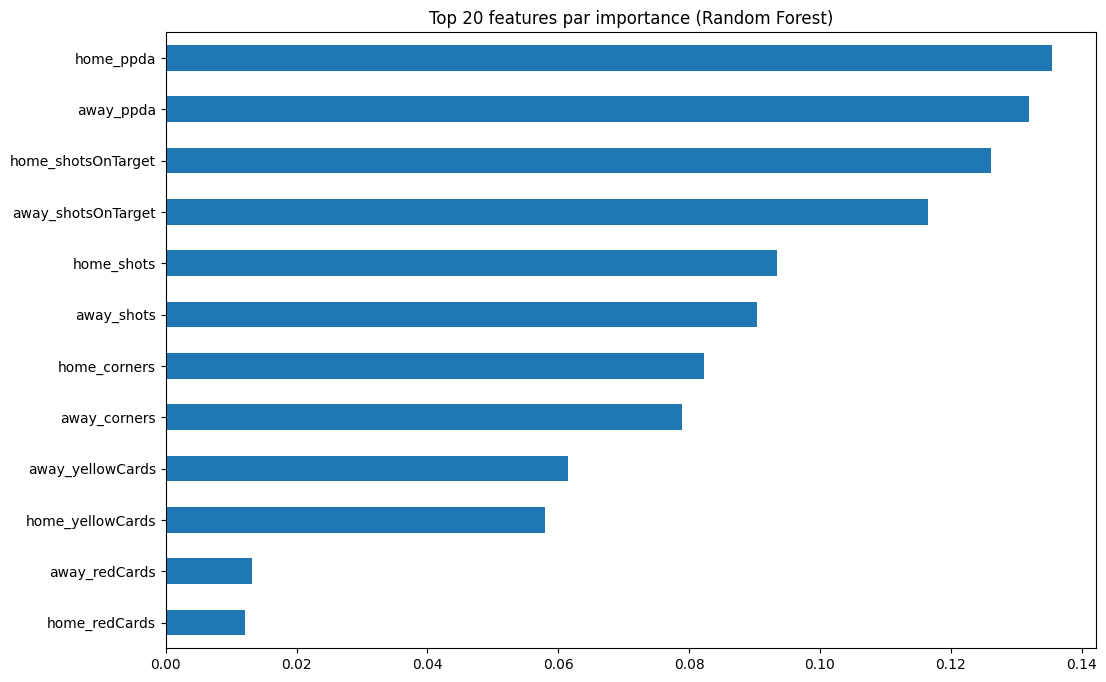

In [ ]:
plt.figure(figsize=(12,8))
importances.head(20).plot(kind='barh')
plt.title("Top 20 features par importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

### Sélection automatique des features (seuil médian)

In [ ]:
# On peut sélectionner automatiquement les features les plus importantes
selector = SelectFromModel(rf, threshold="median", prefit=True)
X_selected = selector.transform(X)

selected_features = X.columns[selector.get_support()]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


### Affichage de la liste des features sélectionnées

In [ ]:
list(selected_features)

['home_shots',
 'home_shotsOnTarget',
 'home_ppda',
 'away_shots',
 'away_shotsOnTarget',
 'away_ppda']

## Création des DataFrames finaux de features et de cible

In [ ]:
X_final = pd.DataFrame(X_selected, columns=selected_features)
y_final = y.copy()

## Affichage des formes du dataset final

In [ ]:
print("Shape X_final:", X_final.shape)
print("Shape y_final:", y_final.shape)

Shape X_final: (12679, 6)
Shape y_final: (12679,)


## Aperçu des features finales

In [ ]:
X_final.head()

,home_shots,home_shotsOnTarget,home_ppda,away_shots,away_shotsOnTarget,away_ppda
0,9.0,1.0,13.8261,9.0,4.0,8.2188
1,11.0,2.0,6.9000,7.0,3.0,11.8462
2,10.0,5.0,6.6500,11.0,5.0,17.1579
3,19.0,8.0,10.8800,11.0,5.0,9.5556
4,17.0,6.0,5.7368,11.0,7.0,10.6250


## Vérification de la distribution finale de la cible

In [ ]:
y_final.value_counts()

,count
target_code,
0,5654
2,3854
1,3171


## Division du dataset en ensembles d'entraînement et de test (X_final)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42, stratify=y)

In [ ]:
scaler = StandardScaler()
# Apprentissage et transformation des données
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# Logistic Regression (Baseline)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    multi_class='multinomial'
)

log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.71      0.61      0.66      1131
           1       0.36      0.42      0.39       634
           2       0.59      0.62      0.61       771

    accuracy                           0.57      2536
   macro avg       0.55      0.55      0.55      2536
weighted avg       0.59      0.57      0.57      2536



# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.67      0.70      0.68      1131
           1       0.36      0.27      0.31       634
           2       0.56      0.63      0.59       771

    accuracy                           0.57      2536
   macro avg       0.53      0.53      0.53      2536
weighted avg       0.56      0.57      0.56      2536



# XGBoost (Performance)

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

In [ ]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.64      0.76      0.69      1131
           1       0.36      0.24      0.29       634
           2       0.59      0.59      0.59       771

    accuracy                           0.58      2536
   macro avg       0.53      0.53      0.52      2536
weighted avg       0.55      0.58      0.56      2536



# Classification hiérarchique (MASTER LEVEL)

1. Home Win vs Not Home Win


In [ ]:
y_train_bin = (y_train == 0).astype(int)
y_test_bin = (y_test == 0).astype(int)

clf_home = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    eval_metric='logloss'
)

clf_home.fit(X_train_scaled, y_train_bin)
home_pred = clf_home.predict(X_test_scaled)

2. Draw vs Away (si Not Home)

In [ ]:
mask_train = y_train != 0
mask_test = y_test != 0

X_train_2 = X_train_scaled[mask_train.values]
y_train_2 = (y_train[mask_train.values] == 1).astype(int)

X_test_2 = X_test_scaled[mask_test.values]
y_test_2 = (y_test[mask_test.values] == 1).astype(int)

clf_draw = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    eval_metric='logloss'
)

clf_draw.fit(X_train_2, y_train_2)
draw_pred = clf_draw.predict(X_test_2)

# Reconstruction finale

In [ ]:
y_pred_hier = np.zeros(len(X_test_scaled), dtype=int)

# First level predictions for all X_test samples
home_preds_all = clf_home.predict(X_test_scaled)

# Assign 'Home Win' (0) where the first model predicts it
y_pred_hier[home_preds_all == 1] = 0

# Get indices where the first model predicted 'Not Home Win'
not_home_win_predicted_indices = np.where(home_preds_all == 0)[0]

# If there are samples predicted as 'Not Home Win', apply the second classifier
if len(not_home_win_predicted_indices) > 0:
    # Select the corresponding X_test samples for the second classifier
    X_test_for_draw_clf = X_test_scaled[not_home_win_predicted_indices]

    # Get predictions from the second classifier (0 for Draw, 1 for Away Win based on y_train_2 mapping)
    draw_away_preds = clf_draw.predict(X_test_for_draw_clf)

    # Map these binary predictions back to the original target_code values:
    # 0 in draw_away_preds means original target_code 1 (Draw)
    # 1 in draw_away_preds means original target_code 2 (Away Win)
    final_stage_preds = np.where(draw_away_preds == 0, 1, 2)

    # Assign these final predictions to the correct positions in y_pred_hier
    y_pred_hier[not_home_win_predicted_indices] = final_stage_preds

In [ ]:
print(classification_report(y_test, y_pred_hier))

              precision    recall  f1-score   support

           0       0.73      0.60      0.66      1131
           1       0.24      0.33      0.28       634
           2       0.27      0.26      0.26       771

    accuracy                           0.43      2536
   macro avg       0.41      0.40      0.40      2536
weighted avg       0.47      0.43      0.44      2536



# Matrices de confusion (GRAPHIQUES)

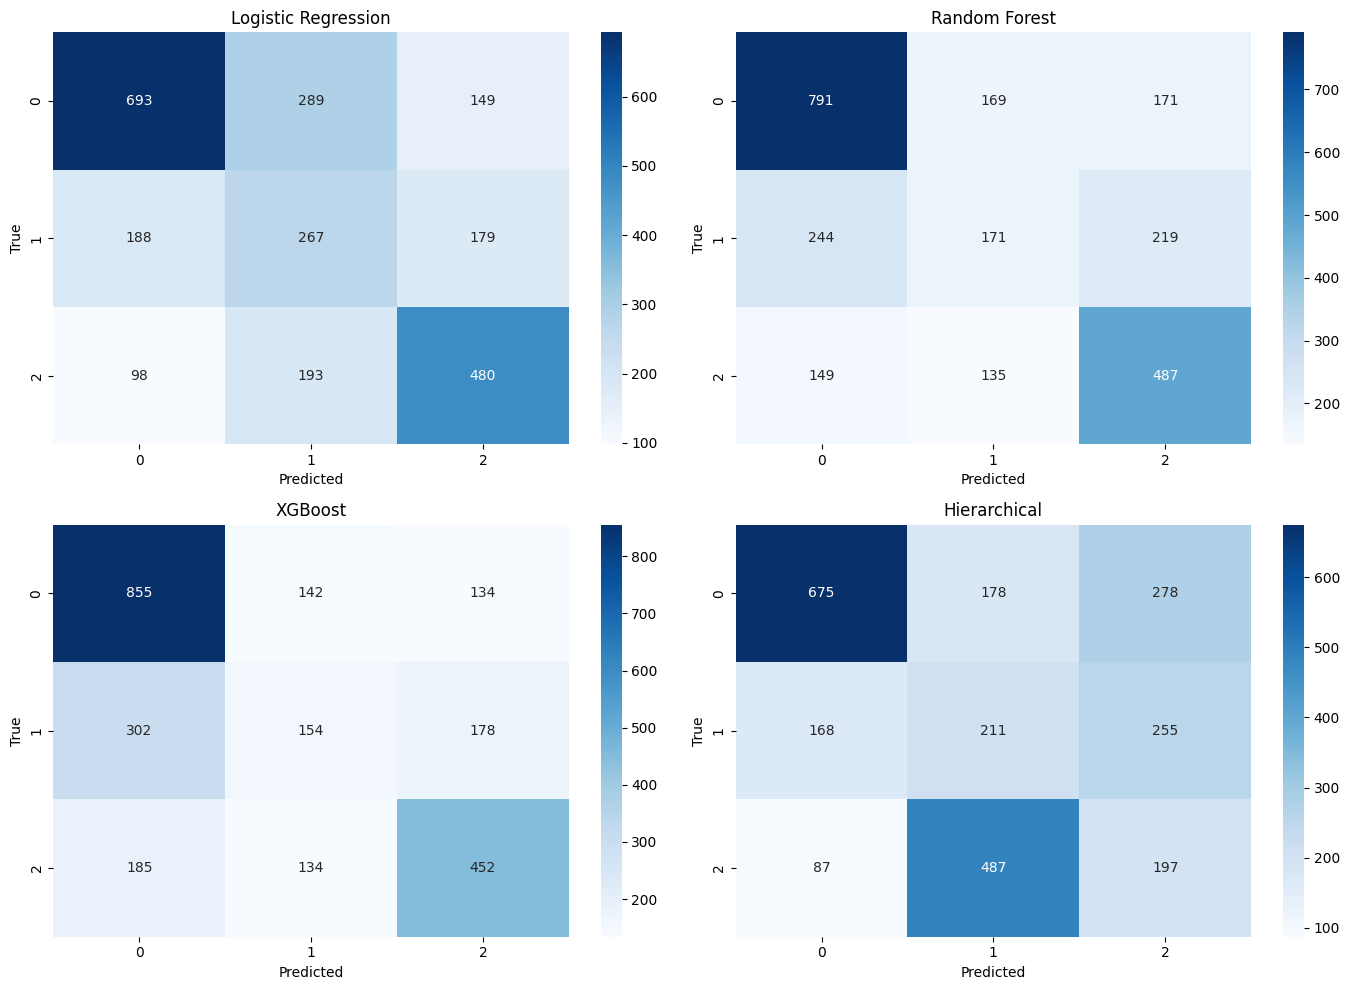

In [ ]:
models = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "Hierarchical": y_pred_hier
}

plt.figure(figsize=(14,10))

for i, (name, y_pred) in enumerate(models.items(), 1):
    plt.subplot(2,2,i)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("True")

plt.tight_layout()
plt.show()

# Comparaison quantitative finale

In [ ]:
results = []

for name, y_pred in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1_macro": f1_score(y_test, y_pred, average='macro'),
        "F1_draw": f1_score(y_test, y_pred, labels=[1], average='macro')
    })

results_df = pd.DataFrame(results)

In [ ]:
print(results_df)

                 Model  Accuracy  F1_macro   F1_draw
0  Logistic Regression  0.567823  0.550323  0.386117
1        Random Forest  0.571372  0.527592  0.308386
2              XGBoost  0.576104  0.523289  0.289474
3         Hierarchical  0.427050  0.398995  0.279470


# Graphe de comparaison

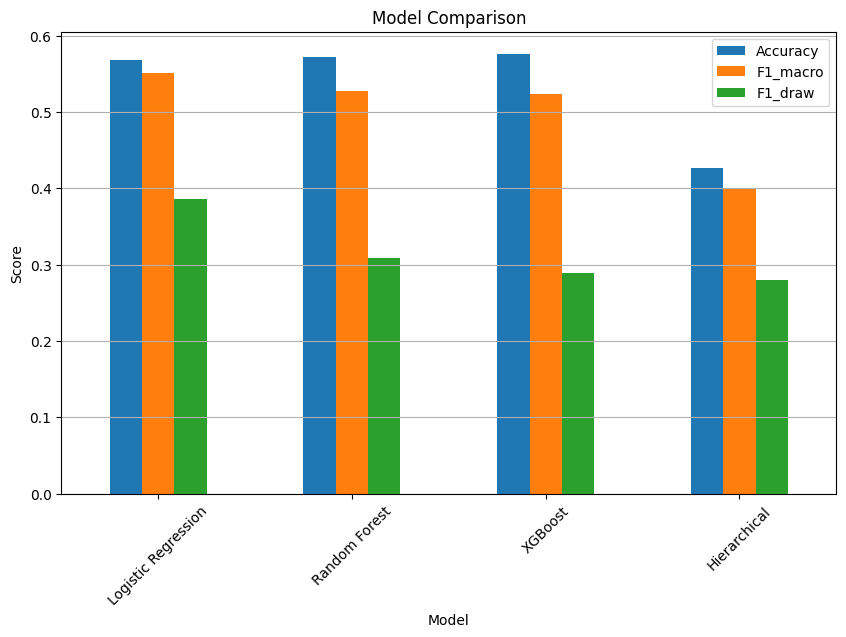

In [ ]:
results_df.set_index("Model")[["Accuracy", "F1_macro", "F1_draw"]].plot(
    kind="bar",
    figsize=(10,6)
)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [ ]:
def select_best_model(results_df, w_macro=0.4, w_draw=0.4, w_acc=0.2):

    df = results_df.copy()

    # Normalisation (optionnelle mais propre)
    for col in ['Accuracy', 'F1_macro', 'F1_draw']:
        df[col + '_norm'] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

    # Score global
    df['Global_Score'] = (w_macro * df['F1_macro_norm'] + w_draw  * df['F1_draw_norm'] + w_acc   * df['Accuracy_norm'])

    # Classement
    df = df.sort_values('Global_Score', ascending=False).reset_index(drop=True)

    best_model_name = df.loc[0, 'Model']

    return best_model_name, df


In [ ]:
best_model, ranking = select_best_model(results_df)

In [ ]:
best_model

'Logistic Regression'

In [ ]:
ranking

,Model,Accuracy,F1_macro,F1_draw,Accuracy_norm,F1_macro_norm,F1_draw_norm,Global_Score
0,Logistic Regression,0.567823,0.550323,0.386117,0.944444,1.000000,1.000000,0.988889
1,Random Forest,0.571372,0.527592,0.308386,0.968254,0.849788,0.271135,0.642020
2,XGBoost,0.576104,0.523289,0.289474,1.000000,0.821355,0.093800,0.566062
3,Hierarchical,0.427050,0.398995,0.279470,0.000000,0.000000,0.000000,0.000000


In [ ]:
import joblib
import os

# Créer un dossier pour les modèles

In [ ]:
MODEL_DIR = folder_path+"/models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Sauvegarder chaque modèle

## Logistic Regression

In [ ]:
joblib.dump(log_reg, f"{MODEL_DIR}/logistic_regression.pkl")

['/content/drive/MyDrive/Predicting-the-results-of-a-match/models/logistic_regression.pkl']

## Random Forest

In [ ]:
joblib.dump(rf, f"{MODEL_DIR}/random_forest.pkl")

['/content/drive/MyDrive/Predicting-the-results-of-a-match/models/random_forest.pkl']

## XGBoost

In [ ]:
joblib.dump(xgb, f"{MODEL_DIR}/xgboost.pkl")

['/content/drive/MyDrive/Predicting-the-results-of-a-match/models/xgboost.pkl']

## Modèle hiérarchique

In [ ]:
joblib.dump(clf_home, f"{MODEL_DIR}/hierarchical_home.pkl")
joblib.dump(clf_draw, f"{MODEL_DIR}/hierarchical_draw.pkl")

['/content/drive/MyDrive/Predicting-the-results-of-a-match/models/hierarchical_draw.pkl']

# Sauvegarder le meilleur modèle

In [ ]:
BEST_MODEL_DIR = folder_path+"/models/best"
os.makedirs(MODEL_DIR, exist_ok=True)

In [ ]:
joblib.dump(log_reg, f"{BEST_MODEL_DIR}/logistic_regression.pkl")

['/content/drive/MyDrive/Predicting-the-results-of-a-match/models/best/logistic_regression.pkl']

# Save feature names

In [ ]:
feature_names_DIR = folder_path+"/models/feature_names"
os.makedirs(feature_names_DIR, exist_ok=True)

In [ ]:
joblib.dump(list(selected_features), f"{feature_names_DIR}/feature_names.pkl")

['/content/drive/MyDrive/Predicting-the-results-of-a-match/models/feature_names/feature_names.pkl']

In [ ]:
selected_features

Index(['home_shots', 'home_shotsOnTarget', 'home_ppda', 'away_shots',
       'away_shotsOnTarget', 'away_ppda'],
      dtype='object')

# Create and save label mapping

In [ ]:
label_mapping_DIR = folder_path+"/models/label_mapping"
os.makedirs(label_mapping_DIR, exist_ok=True)

In [ ]:
label_mapping = df[['target_code', 'target']].drop_duplicates().set_index('target_code')['target'].to_dict()
joblib.dump(label_mapping, f"{label_mapping_DIR}/label_mapping.pkl")

['/content/drive/MyDrive/Predicting-the-results-of-a-match/models/label_mapping/label_mapping.pkl']